SETUP

In [4]:
!pip install networkx numpy pandas scikit-learn matplotlib tqdm

import networkx as nx
import numpy as np
import pandas as pd
import random
from itertools import combinations
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.metrics import mutual_info_score
from sklearn.cluster import KMeans

# Global configuration
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("ZX-CENF Prototype Environment Ready ✔")

ZX-CENF Prototype Environment Ready ✔


GRAPH GENERATION

In [5]:
def generate_zx_graph(num_nodes=10, p_edge=0.25):
    """
    Generate a synthetic ZX-like graph.
    Nodes: Z or X
    """
    G = nx.Graph()

    for i in range(num_nodes):
        node_type = random.choice(["Z", "X"])
        G.add_node(i, type=node_type)

    nodes = list(G.nodes())

    for i, j in combinations(nodes, 2):
        if random.random() < p_edge:
            G.add_edge(i, j)

    return G


# Generate dataset of 100 graphs
NUM_GRAPHS = 100

graphs = [
    generate_zx_graph(num_nodes=random.randint(8, 15))
    for _ in range(NUM_GRAPHS)
]

print(f"Generated {len(graphs)} ZX-like graphs ✔")

Generated 100 ZX-like graphs ✔


VISUALIZATION

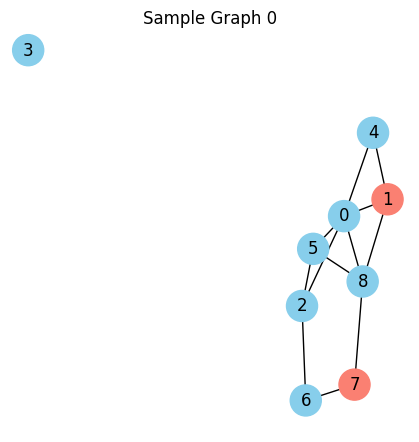

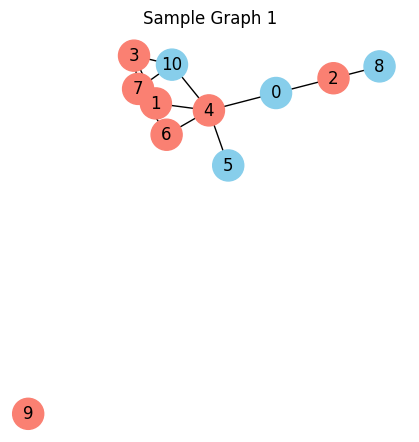

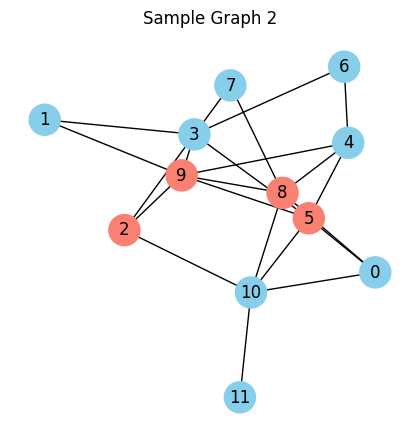

In [6]:
def draw_graph(G, title="ZX Graph"):
    colors = []
    for n in G.nodes():
        if G.nodes[n]["type"] == "Z":
            colors.append("skyblue")
        else:
            colors.append("salmon")

    plt.figure(figsize=(4, 4))
    nx.draw(G, with_labels=True, node_color=colors, node_size=500)
    plt.title(title)
    plt.show()


# Show 3 sample graphs
for i in range(3):
    draw_graph(graphs[i], title=f"Sample Graph {i}")

MOTIF EXTRACTION

In [7]:
def canonical_motif(subgraph):
    """
    Create a canonical representation of a motif.

    We represent a motif using:
    - Node types sorted
    - Adjacency matrix flattened
    """
    nodes = list(subgraph.nodes())

    # Sort nodes by type then id for consistency
    nodes_sorted = sorted(nodes, key=lambda n: subgraph.nodes[n]["type"])

    # Node type signature
    types = tuple(subgraph.nodes[n]["type"] for n in nodes_sorted)

    # Build adjacency matrix
    index = {n: i for i, n in enumerate(nodes_sorted)}
    size = len(nodes_sorted)

    adj = np.zeros((size, size), dtype=int)

    for u, v in subgraph.edges():
        i, j = index[u], index[v]
        adj[i][j] = 1
        adj[j][i] = 1

    return (types, adj.tobytes())


def extract_motifs(graph, k=3):
    """
    Extract all connected k-node motifs from a graph.
    """
    motifs = []

    for nodes in combinations(graph.nodes(), k):
        sub = graph.subgraph(nodes)

        if nx.is_connected(sub):
            motif_id = canonical_motif(sub)
            motifs.append(motif_id)

    return motifs


# Extract motifs for all graphs
graph_motifs = []
global_motif_counts = {}

for G in tqdm(graphs):
    motifs = extract_motifs(G, k=3)
    graph_motifs.append(motifs)

    for m in motifs:
        global_motif_counts[m] = global_motif_counts.get(m, 0) + 1

print("Motif extraction completed.")
print("Unique motifs found:", len(global_motif_counts))

100%|██████████| 100/100 [00:00<00:00, 161.66it/s]

Motif extraction completed.
Unique motifs found: 16


FEATURE MATRIX

In [8]:
unique_motifs = list(global_motif_counts.keys())
motif_index = {m: i for i, m in enumerate(unique_motifs)}

X = np.zeros((len(graphs), len(unique_motifs)))

for gi, motifs in enumerate(graph_motifs):
    for m in motifs:
        X[gi, motif_index[m]] += 1

df_features = pd.DataFrame(X)

print("Feature matrix shape:", df_features.shape)
df_features.head()

Feature matrix shape: (100, 16)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,4.0,2.0,5.0,2.0,1.0,2.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,4.0,3.0,0.0,6.0,3.0,2.0,1.0,2.0,2.0,1.0
2,11.0,3.0,1.0,0.0,3.0,5.0,13.0,6.0,1.0,7.0,4.0,1.0,0.0,2.0,0.0,4.0
3,4.0,1.0,2.0,1.0,0.0,4.0,4.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0
4,1.0,2.0,0.0,0.0,0.0,2.0,4.0,7.0,0.0,7.0,8.0,2.0,1.0,4.0,1.0,4.0


MUTUAL INFORMATION

In [9]:
from sklearn.metrics import mutual_info_score

num_motifs = len(unique_motifs)

# Initialize MI matrix
mi_matrix = np.zeros((num_motifs, num_motifs))

# Convert feature matrix into binary presence (important for MI stability)
binary_X = (X > 0).astype(int)

# Compute MI for each motif pair
for i in range(num_motifs):
    for j in range(i, num_motifs):

        mi = mutual_info_score(binary_X[:, i], binary_X[:, j])

        mi_matrix[i, j] = mi
        mi_matrix[j, i] = mi

print("Mutual Information matrix computed.")
print("Shape:", mi_matrix.shape)

Mutual Information matrix computed.
Shape: (16, 16)


QUICK SANITY CHECK

In [10]:
print("Sample MI values:")
for i in range(min(5, num_motifs)):
    for j in range(min(5, num_motifs)):
        print(f"{mi_matrix[i, j]:.4f}", end=" ")
    print()

Sample MI values:
0.5140 0.1142 0.0895 0.0628 0.1012 
0.1142 0.6769 0.0805 0.0375 0.0427 
0.0895 0.0805 0.6923 0.0571 0.1660 
0.0628 0.0375 0.0571 0.5393 0.0551 
0.1012 0.0427 0.1660 0.0551 0.6859 


MOTIF CLUSTERING

In [11]:
# Feature 1: frequency of each motif
freq = np.array([global_motif_counts[m] for m in unique_motifs])

# Feature 2: MI connectivity (sum of MI with other motifs)
mi_strength = mi_matrix.sum(axis=1)

# Build feature vectors
motif_features = np.vstack([freq, mi_strength]).T

# Normalize features
motif_features = (motif_features - motif_features.mean(axis=0)) / (motif_features.std(axis=0) + 1e-9)

# KMeans clustering
NUM_CLUSTERS = 5

kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
clusters = kmeans.fit_predict(motif_features)

print("Clustering completed.")
print("Number of clusters:", NUM_CLUSTERS)

Clustering completed.
Number of clusters: 5


CLUSTER SUMMARY

In [12]:
cluster_summary = {}

for i, c in enumerate(clusters):
    cluster_summary.setdefault(c, []).append(unique_motifs[i])

for c, motifs in cluster_summary.items():
    print(f"\nCluster {c}: {len(motifs)} motifs")


Cluster 1: 2 motifs

Cluster 3: 7 motifs

Cluster 0: 3 motifs

Cluster 2: 2 motifs

Cluster 4: 2 motifs


REWRITE PRIORITIES

In [13]:
# Compute cluster-level statistics
cluster_freq = {}
cluster_mi = {}

for i, c in enumerate(clusters):
    cluster_freq.setdefault(c, 0)
    cluster_mi.setdefault(c, 0)

    cluster_freq[c] += freq[i]
    cluster_mi[c] += mi_strength[i]

# Normalize cluster scores
cluster_scores = {}

for c in cluster_freq:
    score = cluster_freq[c] + 0.5 * cluster_mi[c]
    cluster_scores[c] = score

# Normalize to priority scale (1–10)
max_score = max(cluster_scores.values())
min_score = min(cluster_scores.values())

cluster_priority = {}

for c, score in cluster_scores.items():
    if max_score == min_score:
        priority = 5
    else:
        priority = 1 + 9 * (score - min_score) / (max_score - min_score)

    cluster_priority[c] = priority

print("Cluster priorities assigned:")
for c, p in cluster_priority.items():
    print(f"Cluster {c}: Priority {p:.2f}")

Cluster priorities assigned:
Cluster 1: Priority 6.72
Cluster 3: Priority 10.00
Cluster 0: Priority 1.00
Cluster 2: Priority 6.76
Cluster 4: Priority 7.28


MOTIF PRIORITY MAP

In [14]:
motif_priority = {}

for i, motif in enumerate(unique_motifs):
    cluster = clusters[i]
    motif_priority[motif] = cluster_priority[cluster]

print("Motif priority mapping created.")

Motif priority mapping created.


GRAPH REWRITE ENGINE

In [17]:
def rewrite_graph(G, k=3, threshold=7):
    """
    Improved graph rewriting.

    Rules:
    - Each node can only participate in one rewrite.
    - Only high-priority motifs are rewritten.
    - External connectivity is preserved.
    """

    G_new = G.copy()

    rewritten_nodes = set()

    candidate_motifs = []


    # Find candidate motifs
    for nodes in combinations(G.nodes(), k):

        sub = G.subgraph(nodes)

        if not nx.is_connected(sub):
            continue

        motif = canonical_motif(sub)

        if motif not in motif_priority:
            continue

        priority = motif_priority[motif]

        if priority >= threshold:
            candidate_motifs.append((priority, nodes))

    # Highest priority first
    candidate_motifs.sort(reverse=True)

    # Apply rewrites
    for priority, nodes in candidate_motifs:

        # Skip overlapping motifs
        if any(node in rewritten_nodes for node in nodes):
            continue

        # Ensure nodes still exist
        if not all(node in G_new.nodes for node in nodes):
            continue

        external_neighbors = set()

        for node in nodes:
            for neigh in G_new.neighbors(node):
                if neigh not in nodes:
                    external_neighbors.add(neigh)

        # Representative node type
        types = [G_new.nodes[n]["type"] for n in nodes]

        representative = "Z"

        if types.count("X") > types.count("Z"):
            representative = "X"

        new_node = max(G_new.nodes) + 1

        G_new.add_node(new_node, type=representative)

        for neigh in external_neighbors:
            G_new.add_edge(new_node, neigh)

        G_new.remove_nodes_from(nodes)

        rewritten_nodes.update(nodes)

    return G_new


# Optimize all graphs
optimized_graphs = []

for G in tqdm(graphs):
    optimized_graphs.append(rewrite_graph(G))

print("Improved graph rewriting completed.")

100%|██████████| 100/100 [00:00<00:00, 129.50it/s]

Improved graph rewriting completed.


EVALUATION

In [20]:
original_nodes = []
optimized_nodes = []

original_edges = []
optimized_edges = []

for G, G_opt in zip(graphs, optimized_graphs):

    original_nodes.append(G.number_of_nodes())
    optimized_nodes.append(G_opt.number_of_nodes())

    original_edges.append(G.number_of_edges())
    optimized_edges.append(G_opt.number_of_edges())


original_nodes = np.array(original_nodes)
optimized_nodes = np.array(optimized_nodes)

original_edges = np.array(original_edges)
optimized_edges = np.array(optimized_edges)


node_reduction = original_nodes - optimized_nodes
edge_reduction = original_edges - optimized_edges


print("ZX-CENF Optimization Summary")
print("-" * 30)

print(f"Average Original Nodes    : {original_nodes.mean():.2f}")
print(f"Average Optimized Nodes   : {optimized_nodes.mean():.2f}")
print(f"Average Node Reduction    : {node_reduction.mean():.2f}")

print()

print(f"Average Original Edges    : {original_edges.mean():.2f}")
print(f"Average Optimized Edges   : {optimized_edges.mean():.2f}")
print(f"Average Edge Reduction    : {edge_reduction.mean():.2f}")

print()

print(f"Node Reduction (%)        : {100 * node_reduction.mean() / original_nodes.mean():.2f}%")
print(f"Edge Reduction (%)        : {100 * edge_reduction.mean() / original_edges.mean():.2f}%")

ZX-CENF Optimization Summary
------------------------------
Average Original Nodes    : 11.79
Average Optimized Nodes   : 7.05
Average Node Reduction    : 4.74

Average Original Edges    : 16.41
Average Optimized Edges   : 8.13
Average Edge Reduction    : 8.28

Node Reduction (%)        : 40.20%
Edge Reduction (%)        : 50.46%


VISUAL COMPARISON

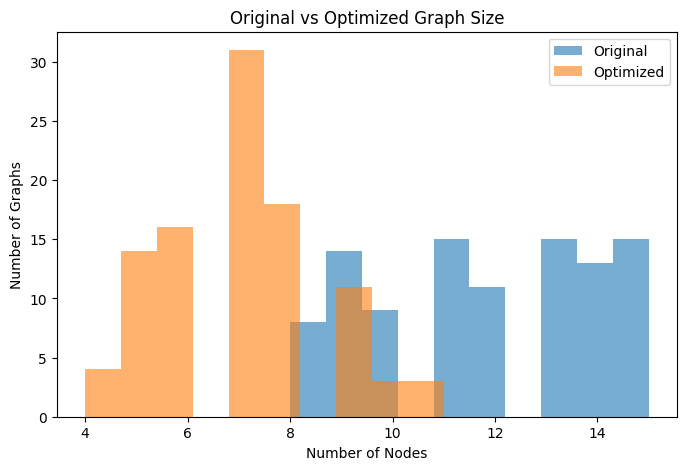

In [21]:
plt.figure(figsize=(8,5))

plt.hist(original_nodes,
         bins=10,
         alpha=0.6,
         label="Original")

plt.hist(optimized_nodes,
         bins=10,
         alpha=0.6,
         label="Optimized")

plt.xlabel("Number of Nodes")
plt.ylabel("Number of Graphs")
plt.title("Original vs Optimized Graph Size")

plt.legend()

plt.show()